# Mechanism probe: alias swap and layerwise logit lens

This experiment separates semantic candidate selection from answer-token
preference. It uses 16 non-tie N=32 examples (four each at
r=0.1, 0.3, 0.7, 0.9), swaps the X/Y alias assignment while holding
all evidence fixed, and crosses that intervention with underscore and
period fillers at F = 0,1,2,4,8,11,16,32,64,100.

At every embedding/layer depth, the ordinary final RMS norm and output
head measure logits for X, Y, and `=` at the exact position after
`FINAL: `. No text is generated; thinking is explicitly disabled.
Alias-swap semantic consistency asks whether the *same numeric candidate*
is selected after its output alias changes.


In [1]:
from __future__ import annotations

import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the MATS repository.")


def load_jsonl(path: Path) -> list[dict[str, object]]:
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()]


REPO_ROOT = find_repo_root()
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "filler_token_probe"
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
results_path = ARTIFACT_DIR / "mechanism_results.jsonl"
manifest_path = ARTIFACT_DIR / "mechanism_manifest.json"
rows = load_jsonl(results_path)
manifest = json.loads(manifest_path.read_text())
final_layer = max(row["layer"] for row in rows)
final = [row for row in rows if row["layer"] == final_layer]
filler_counts = [0, 1, 2, 4, 8, 11, 16, 32, 64, 100]
fillers = ["underscore", "period"]

assert len(rows) == 21_120 and len(final) == 640
assert set(row["layer"] for row in rows) == set(range(33))
assert manifest["protocol"]["enable_thinking"] is False
assert manifest["protocol"]["generated_reasoning_tokens"] == 0
assert manifest["protocol"]["answer_token_ids"] == {"X": 55, "Y": 56, "=": 28}
assert all(row["enable_thinking"] is False for row in rows)
cells = Counter(
    (row["filler"], row["filler_count"], row["alias_condition"])
    for row in final
)
assert len(cells) == 40 and set(cells.values()) == {16}

for filler in fillers:
    for f in filler_counts:
        group = [row for row in final if row["filler"] == filler and row["filler_count"] == f]
        paired = defaultdict(set)
        for row in group:
            paired[row["example_id"]].add(row["alias_condition"])
        assert len(paired) == 16 and all(value == {"original", "swapped"} for value in paired.values())

print("Causal-pair and 33-depth coverage: PASS")
print("layer records:", len(rows), "final records:", len(final))


Causal-pair and 33-depth coverage: PASS
layer records: 21120 final records: 640


## Causal alias-swap result


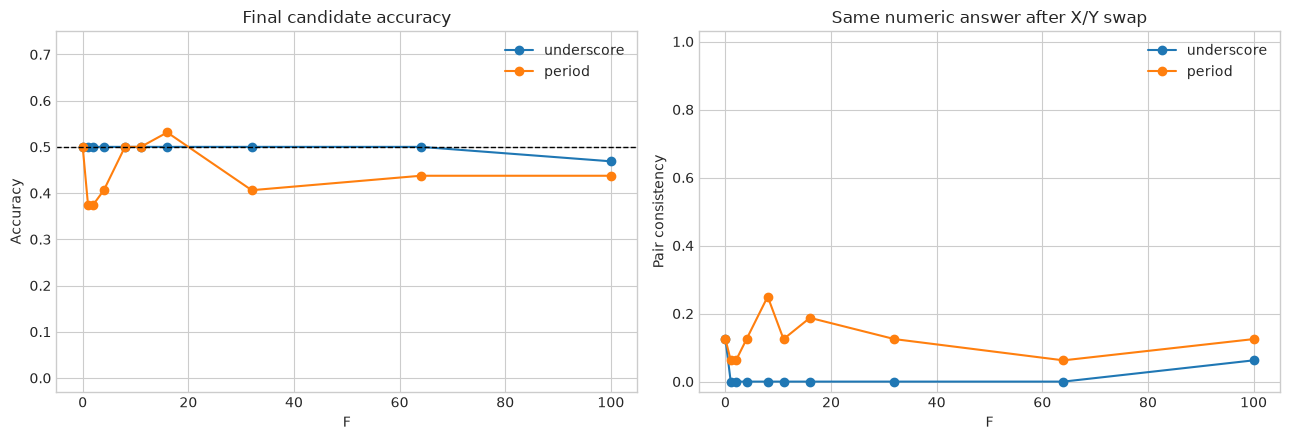

underscore
  mean accuracy: 0.497
  mean semantic consistency: 0.019
  mean surface-token invariance: 0.981
period
  mean accuracy: 0.447
  mean semantic consistency: 0.125
  mean surface-token invariance: 0.706


In [3]:
surface_accuracy = {filler: [] for filler in fillers}
semantic_consistency = {filler: [] for filler in fillers}
surface_invariance = {filler: [] for filler in fillers}
for filler in fillers:
    for f in filler_counts:
        group = [
            row for row in final
            if row["filler"] == filler and row["filler_count"] == f
        ]
        surface_accuracy[filler].append(np.mean([row["correct"] for row in group]))
        pairs = defaultdict(dict)
        for row in group:
            pairs[row["example_id"]][row["alias_condition"]] = row
        semantic_consistency[filler].append(np.mean([
            pair["original"]["predicted_answer"] == pair["swapped"]["predicted_answer"]
            for pair in pairs.values()
        ]))
        surface_invariance[filler].append(np.mean([
            pair["original"]["predicted_surface"] == pair["swapped"]["predicted_surface"]
            for pair in pairs.values()
        ]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for filler in fillers:
    axes[0].plot(filler_counts, surface_accuracy[filler], marker="o", label=filler)
    axes[1].plot(filler_counts, semantic_consistency[filler], marker="o", label=filler)
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set(xlabel="F", ylabel="Accuracy", title="Final candidate accuracy", ylim=(-0.03, 0.75))
axes[1].set(xlabel="F", ylabel="Pair consistency",
            title="Same numeric answer after X/Y swap", ylim=(-0.03, 1.03))
for ax in axes:
    ax.legend()
fig.tight_layout()
figure_path = ARTIFACT_DIR / "exp3_alias_swap.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

for filler in fillers:
    print(filler)
    print("  mean accuracy:", round(float(np.mean(surface_accuracy[filler])), 3))
    print("  mean semantic consistency:",
          round(float(np.mean(semantic_consistency[filler])), 3))
    print("  mean surface-token invariance:",
          round(float(np.mean(surface_invariance[filler])), 3))


## Layerwise answer-token dynamics


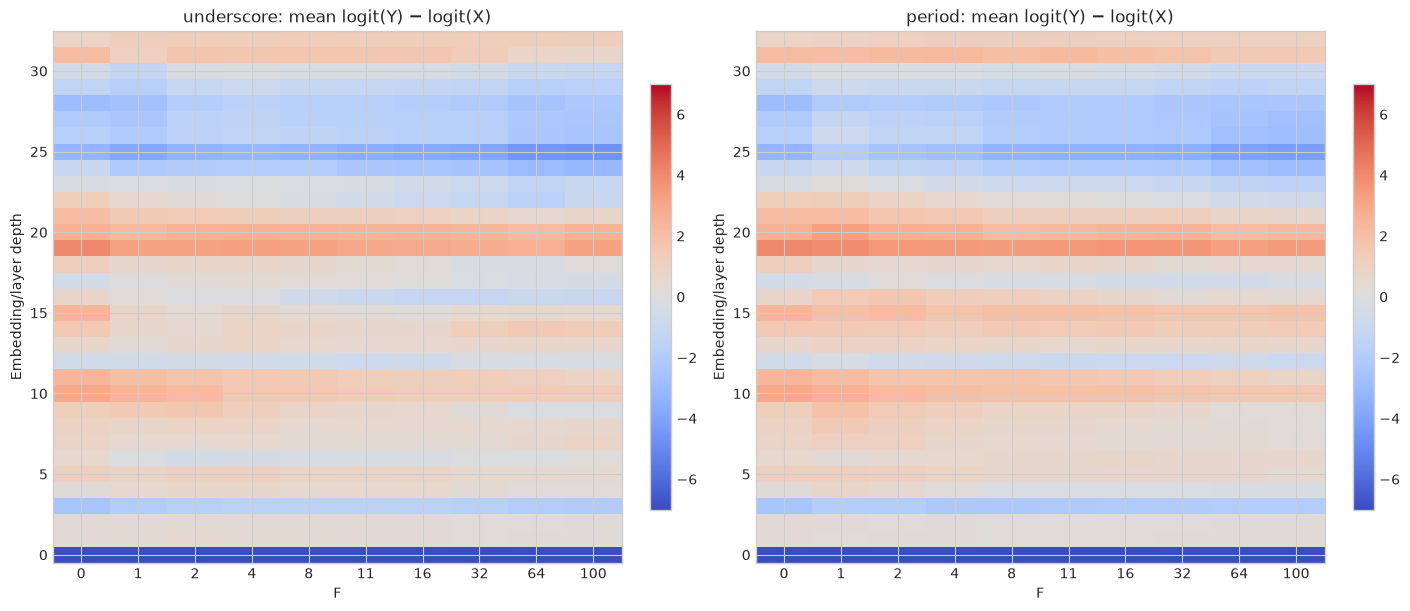

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, filler in zip(axes, fillers, strict=True):
    matrix = np.empty((33, len(filler_counts)))
    for layer in range(33):
        for j, f in enumerate(filler_counts):
            group = [
                row for row in rows
                if row["layer"] == layer
                and row["filler"] == filler
                and row["filler_count"] == f
            ]
            matrix[layer, j] = np.mean([
                row["answer_logits"]["Y"] - row["answer_logits"]["X"]
                for row in group
            ])
    limit = max(abs(np.nanmin(matrix)), abs(np.nanmax(matrix)))
    image = ax.imshow(matrix, aspect="auto", origin="lower", cmap="coolwarm",
                      vmin=-limit, vmax=limit)
    ax.set_xticks(range(len(filler_counts)), filler_counts)
    ax.set(xlabel="F", ylabel="Embedding/layer depth",
           title=f"{filler}: mean logit(Y) − logit(X)")
    fig.colorbar(image, ax=ax, shrink=0.8)
figure_path = ARTIFACT_DIR / "exp3_layerwise_y_minus_x.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()


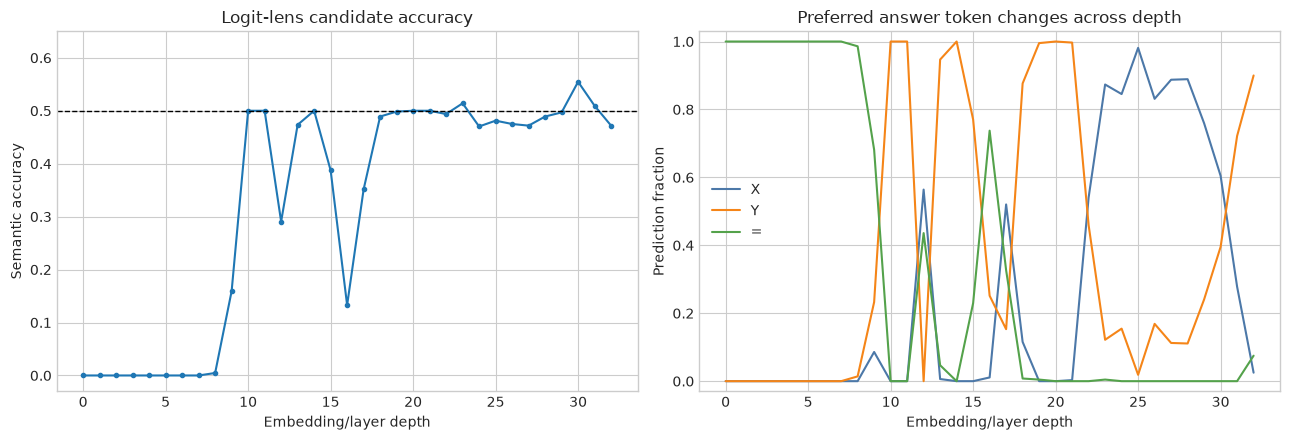

final prediction counts: {'Y': 576, 'X': 16, '=': 48}
final semantic accuracy: 0.472


In [5]:
layer_accuracy = []
layer_predictions = []
for layer in range(33):
    group = [row for row in rows if row["layer"] == layer]
    layer_accuracy.append(np.mean([row["correct"] for row in group]))
    layer_predictions.append(Counter(row["predicted_surface"] for row in group))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(range(33), layer_accuracy, marker="o", markersize=3)
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set(xlabel="Embedding/layer depth", ylabel="Semantic accuracy",
            title="Logit-lens candidate accuracy", ylim=(-0.03, 0.65))

for surface, color in (("X", "#4c78a8"), ("Y", "#f58518"), ("=", "#54a24b")):
    axes[1].plot(
        range(33),
        [counts[surface] / 640 for counts in layer_predictions],
        label=surface,
        color=color,
    )
axes[1].set(xlabel="Embedding/layer depth", ylabel="Prediction fraction",
            title="Preferred answer token changes across depth", ylim=(-0.03, 1.03))
axes[1].legend()
fig.tight_layout()
figure_path = ARTIFACT_DIR / "exp3_layerwise_predictions.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("final prediction counts:", dict(layer_predictions[-1]))
print("final semantic accuracy:", round(float(layer_accuracy[-1]), 3))


## Interpretation

The intervention supports a readout-bias account. Underscore fillers
produce `Y` on 317 of 320 final prompts. Because the same surface token
denotes the opposite numeric candidate after an alias swap, mean
semantic consistency is only 0.019, despite 0.497 mean accuracy.
Period is somewhat less deterministic but still has only 0.125 mean
semantic consistency. A robust internal candidate choice would instead
switch output tokens and preserve the numeric answer.

The layerwise lens also rules out a simple story in which the same
answer preference is present at every depth: the favored restricted
token moves from tie in early layers, through X/Y phases, to a strong Y
preference at the final readout. A logit lens is descriptive rather
than a faithful decoder of intermediate computations, but together
with the causal alias swap it shows that filler-dependent accuracy is
dominated by the output surface. These probes therefore do not support
treating filler tokens as hidden reasoning time.
